# Computer Vision Assignments: Sessions 1 & 2

This notebook contains tasks and assignments based on Sessions 1 and 2. You are required to implement the functions and complete the exercises as described. Use OpenCV and other necessary libraries like NumPy and Matplotlib.

**Instructions:**
- Complete each task in the provided code cells.
- Test your implementations with sample images (e.g., download test images [here](https://sipi.usc.edu/database/database.php?volume=misc) or [here](https://www.hlevkin.com/hlevkin/06testimages.htm) or use your own test images).
- Include comments in your code for clarity.
- Display results using cv2.imshow() or Matplotlib where appropriate.
- Submit the completed notebook along with any output images or explanations on [our google drive for the CV sessions](https://drive.google.com/drive/folders/1IjVhJmAXxNQTGT-ybJ-yc5smYtR5v8CO?usp=sharing) **upload your files in a new folder under your name**

## Session 1: Basic Image Operations (Reading, Resizing, Cropping, Rotating)

### Task 1: Read and Display an Image
Read an image from a file and display it in both BGR and grayscale formats. Handle errors if the image cannot be read.

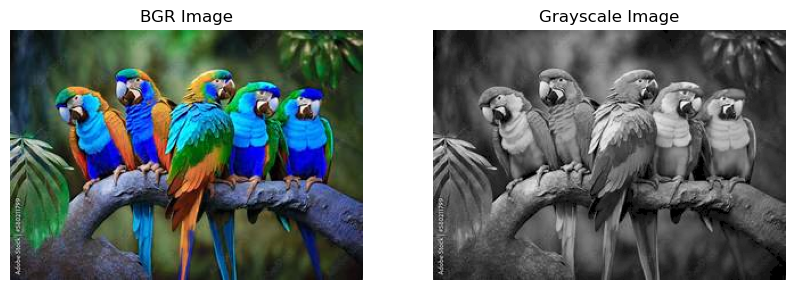

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
#Task 1
path = 'C:\\Users\\Prof. Ahmed ElShafee\\Documents\\Python Projects\\parrot.jpg'
read_image=cv.imread(path)
img = cv.imread("parrot.png")
#BGR has 3 channels -> Blue, Green, Red
#Grayscale images have 1 channel only -> this channel represents the brightness of the pixel starting from 0 (black) to 255 (white)

img_bgr=cv.imread("parrot.png", cv.IMREAD_COLOR) #cv2.imread() func reads the image in BGR order 
img_gray=cv.imread("parrot.png", cv.IMREAD_GRAYSCALE) #cv2.imread() func reads the image in grayscale order 
#Display both
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(img_bgr)
plt.title("BGR Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img_gray, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")

plt.show()
 

### Task 2: Resize Image with Aspect Ratio Preservation
Implement resizing while preserving aspect ratio. Downscale to 60% and upscale to 200%. Compare shapes and display originals vs resized.

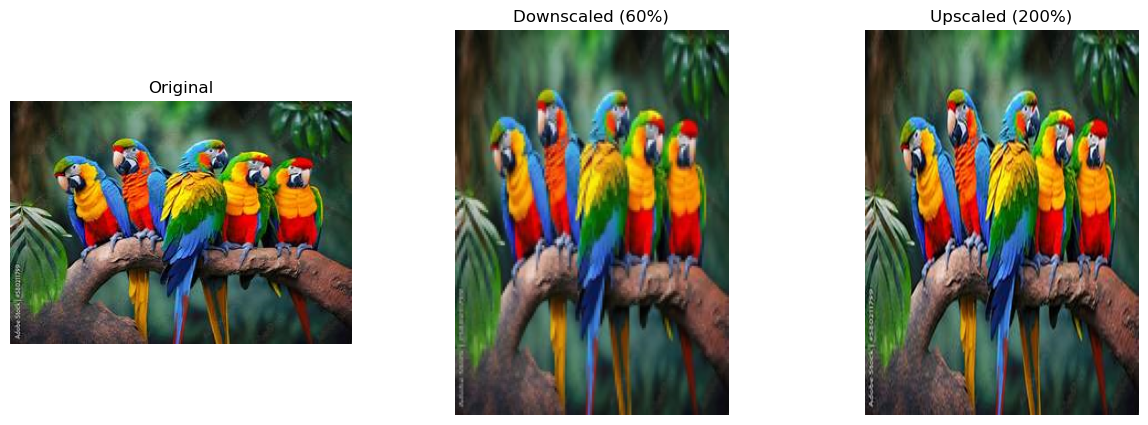

In [ ]:
#Task 2
#DOWNSCALING
scale= 60
#height=scale*height/100 width=scale*width/100
h,w , _= img.shape
h= int(scale*h / 100)
w= int(scale*w / 100 )
dim= (h,w)

downscaled_img= cv.resize(img, dim , interpolation = cv.INTER_AREA) #interpolation determines how opencv will be calculating the pixels in the new image
#cv.INTER_AREA is usually used when downscalling an image
#cv.INTER_CUBIC is higher quality but slow and it's commonly used when upscaling an image
#cv.INTER_NEAREST is fastest but low quality and makes the image look pixelated 

#UPSCALING
scale= 200
h,w , _= img.shape
h= int(scale *h / 100)
w= int(scale * w / 100 )
dim= (h,w)
upscaled_img= cv.resize(img, dim , interpolation = cv.INTER_CUBIC)  #i used INTER_CUBIC because it is better for upscaling (good quality images)

#Display the images

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(cv.cvtColor(downscaled_img, cv.COLOR_BGR2RGB))
plt.title("Downscaled (60%)")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(cv.cvtColor(upscaled_img, cv.COLOR_BGR2RGB))
plt.title("Upscaled (200%)")
plt.axis("off")

plt.show()

### Task 3: Resize Without Preserving Aspect Ratio
Resize only width to 100 pixels, only height to 200 pixels, and both to (200, 200). Display and discuss distortions.

Original image shape:  (220, 310, 3)


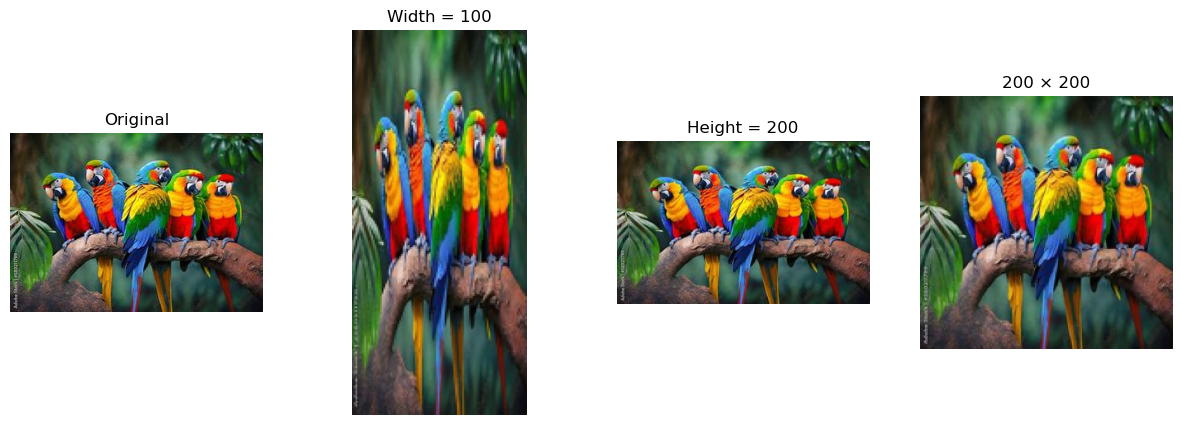

In [12]:
#Task 3
print("Original image shape: ", img.shape)

h, w, _= img.shape
#Resize width to 100 pixels
dim= (100, h)
width_img= cv.resize(img, dim, interpolation=cv.INTER_AREA)

#Resize only height to 200 pixels
dim= (w, 200)
height_img= cv.resize(img, dim, interpolation=cv.INTER_AREA)

#Resize both width and height to 200 pixels
h= 200
w= 200
dim= (w, h)
HW_img = cv.resize(img, dim, interpolation=cv.INTER_AREA)

plt.figure(figsize=(15, 5))

plt.subplot(1, 4, 1)
plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
plt.title("Original")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(cv.cvtColor(width_img, cv.COLOR_BGR2RGB))
plt.title("Width = 100") #when the width changed and the height stayed the same, the image looked narrower and compressed
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(cv.cvtColor(height_img, cv.COLOR_BGR2RGB))
plt.title("Height = 200") #when the height changed and the width stayed the same, the image looked taller and stretched vertically
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(cv.cvtColor(HW_img, cv.COLOR_BGR2RGB))
plt.title("200 × 200") #both dimensions got compressed and the image tends to look like a square
plt.axis("off")

plt.show()

### Task 4: Resize Using Scale Factors (fx, fy)
Scale up by 1.2 in both directions and down by 0.6. Use different interpolations (INTER_LINEAR, INTER_NEAREST) and compare quality.

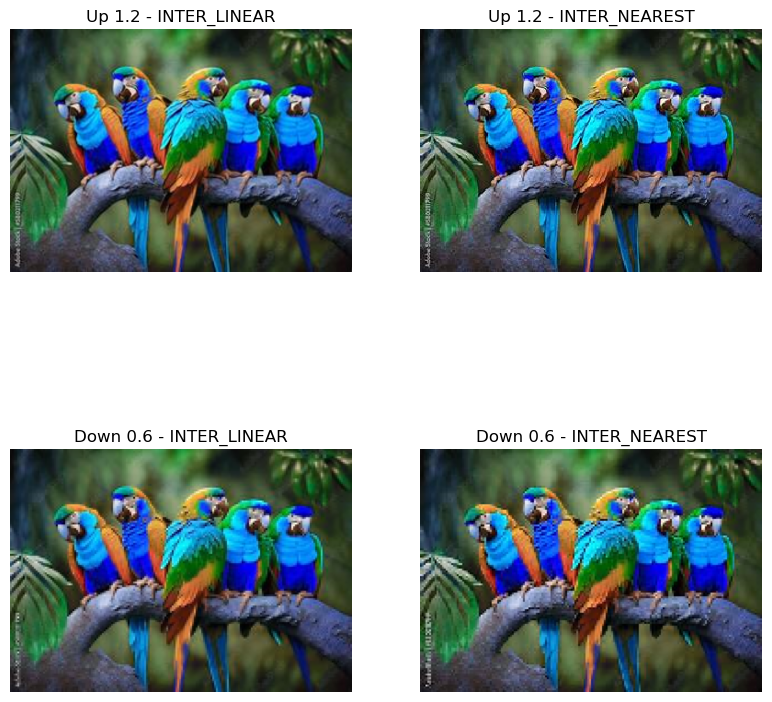

In [ ]:
#Task 4
#Scale up by 1.2 using INTER_LINEAR
up_linear= cv.resize(
    img, None, fx=1.2, fy=1.2, interpolation=cv.INTER_LINEAR
)

#Scale up by 1.2 using INTER_NEAREST
up_nearest= cv.resize(
    img, None, fx=1.2, fy=1.2, interpolation=cv.INTER_NEAREST
)

#Scale down by 0.6 using INTER_LINEAR
down_linear= cv.resize(
    img, None, fx=0.6, fy=0.6, interpolation=cv.INTER_LINEAR
)

#Scale down by 0.6 using INTER_NEAREST
down_nearest= cv.resize(
    img, None, fx=0.6, fy=0.6, interpolation=cv.INTER_NEAREST
)

#Display
plt.figure(figsize=(15, 10))


plt.subplot(2, 3, 2)
plt.imshow(up_linear)
plt.title("Up 1.2 - INTER_LINEAR")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(up_nearest)
plt.title("Up 1.2 - INTER_NEAREST")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(down_linear)
plt.title("Down 0.6 - INTER_LINEAR")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(down_nearest)
plt.title("Down 0.6 - INTER_NEAREST")
plt.axis("off")

plt.show()
#INTER_LINEAR produces smoother results when upscaling because
#it calculates new pixel values using neighboring pixels.
#INTER_NEAREST uses the value of the nearest pixel, which can
#make the enlarged image appear more pixelated.

#When downscaling, INTER_LINEAR generally produces smoother results,
#while INTER_NEAREST can lose more detail and produce a rougher appearance..

### Task 5: Cropping an Image
Crop a region (e.g., [20:200, 50:200]) from the image. Display original and cropped.

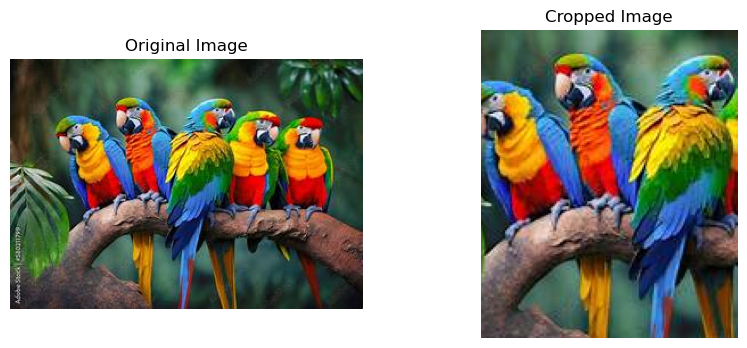

In [17]:
# Task 5

cropped_img= img[20:200, 50:200]

img_rgb= cv.cvtColor(img, cv.COLOR_BGR2RGB)
cropped_rgb= cv.cvtColor(cropped_img, cv.COLOR_BGR2RGB)

# Display
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cropped_rgb)
plt.title("Cropped Image")
plt.axis("off")

plt.show()

### Task 6: Advanced Cropping - Patch Image into Blocks
Divide the image into 4 equal blocks (2x2 grid) by cropping. Display each block separately and then stitch them back using NumPy concatenation to verify.

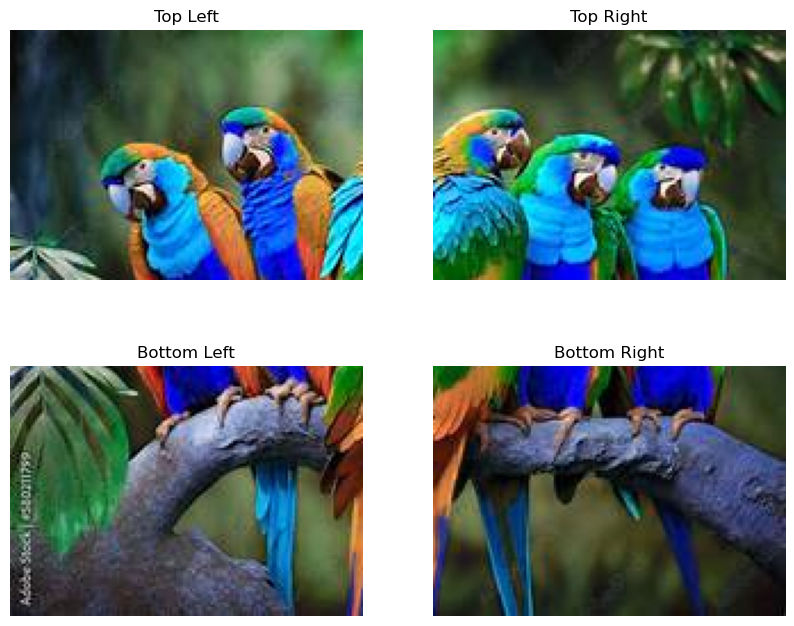

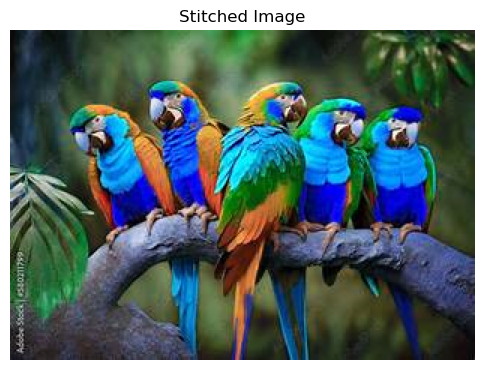

In [19]:
#Task 6

#Calculate midpoints
h, w, _= img.shape
mid_h=h // 2
mid_w=w // 2

#Cropping into 4 blocks
top_left= img[0:mid_h, 0:mid_w]
top_right= img[0:mid_h, mid_w:w]
bottom_left= img[mid_h:h, 0:mid_w]
bottom_right= img[mid_h:h, mid_w:w]

#Then stitching the blocks back together to form the original image
top=np.hstack((top_left, top_right))
bottom=np.hstack((bottom_left, bottom_right))
stitched_img=np.vstack((top, bottom))


#Display the 4 blocks
plt.figure(figsize=(10, 8))

plt.subplot(2, 2, 1)
plt.imshow(top_left)
plt.title("Top Left")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(top_right)
plt.title("Top Right")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(bottom_left)
plt.title("Bottom Left")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(bottom_right)
plt.title("Bottom Right")
plt.axis("off")

plt.show()


#Display stitched image
plt.figure(figsize=(6, 5))
plt.imshow(stitched_img)
plt.title("Stitched Image")
plt.axis("off")
plt.show()

### Task 7: Rotating an Image
Rotate the image by 45°, 90°, and 180° using getRotationMatrix2D and warpAffine. Display all rotations.

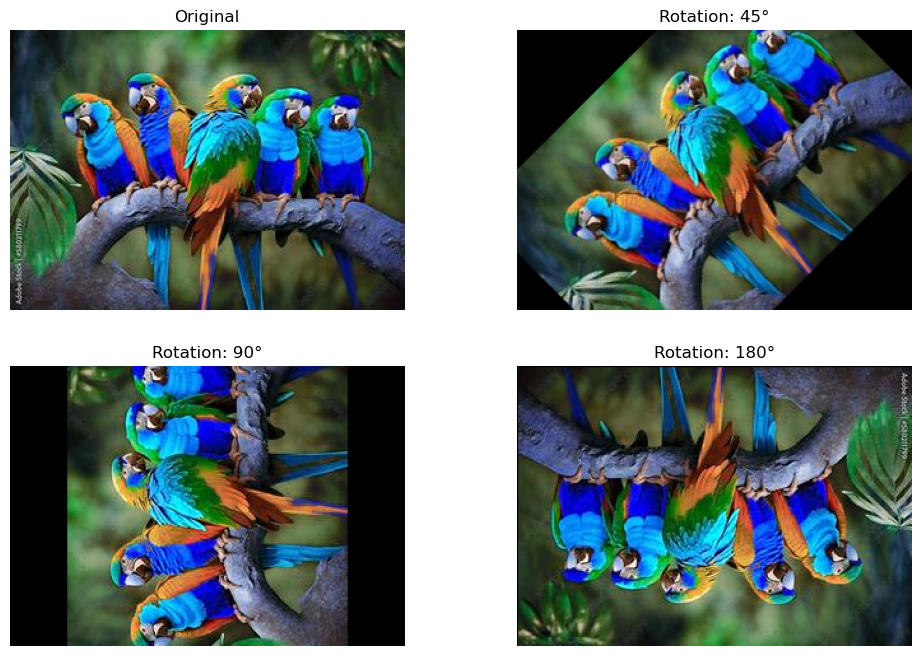

In [22]:
#Task 7
height, width, _= img.shape
#Calculate the center of the image
center=(width/2,height/2)

#rotation matrix for 45 degrees
rotate_matrix= cv.getRotationMatrix2D(center=center,angle=45,scale=1) #creates the matrix needed to rotate the image around its center
#The 45 rotation tilts the image diagonally. Since the output size remains the same,the corners is cut off

#Rotate the image using warpAffine
rotated_image_45= cv.warpAffine(src=img,M=rotate_matrix,dsize=(width, height)) #applies the rotation matrix to the image



#rotation matrix for 90 degrees
rotate_matrix_90= cv.getRotationMatrix2D(center=center,angle=90,scale=1) #The 90 rotation turns the image sideways

#rotation matrix for 180 degrees
rotate_matrix_180= cv.getRotationMatrix2D(center=center,angle=180,scale=1) #The 180 rotation turns the image upside down.

rotated_image_90= cv.warpAffine(src=img,M=rotate_matrix_90,dsize=(width, height))
rotated_image_180= cv.warpAffine(src=img,M=rotate_matrix_180,dsize=(width, height))
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.imshow(img)
plt.title("Original")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(rotated_image_45)
plt.title("Rotation: 45°")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(rotated_image_90)
plt.title("Rotation: 90°")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(rotated_image_180)
plt.title("Rotation: 180°")
plt.axis("off")

plt.show()

### Task 8: Rotate with Scaling
Rotate by 45° and scale by 0.5 in **one** operation. Compare with separate resize and rotate.

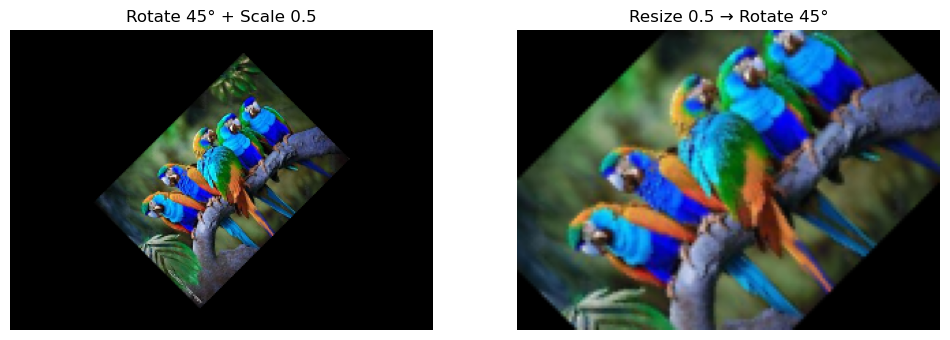

In [ ]:
height, width, _=img.shape
center=(width / 2, height / 2)

rotate_matrix = cv.getRotationMatrix2D(center=center,angle=45,scale=0.5) #when scale is 1, there is no resizing
rotated_scaled = cv.warpAffine(src=img,M=rotate_matrix,dsize=(width, height))

resized = cv.resize(img,None,fx=0.5,fy=0.5,interpolation=cv.INTER_LINEAR)
#Get the new height and width beacuse the image has been resized
new_height, new_width, _ = resized.shape
new_center = (new_width / 2, new_height / 2)
rotate_matrix_separate = cv.getRotationMatrix2D(center=new_center,angle=45,scale=1)
rotated_separate = cv.warpAffine(src=resized,M=rotate_matrix_separate,dsize=(new_width, new_height))
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(rotated_scaled)
plt.title("Rotate 45° + Scale 0.5")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(rotated_separate)
plt.title("Resize 0.5 → Rotate 45°")
plt.axis("off")

plt.show()
#When rotation and scaling are performed in one operation, the image is scaled around the center of the original canvas, so the output keeps the original dimnsions.
#When resizing is performed first, the image and its canvas are both reduced before rotation, resulting in a smaller final output.


## Session 2: Image Acquisition, Formats, Color Spaces, Enhancement, and Filtering

### Task 9: Read Image in Different Color Spaces
Read an image in BGR, convert to RGB (for Matplotlib), HSV, LAB and Grayscale. Display all.

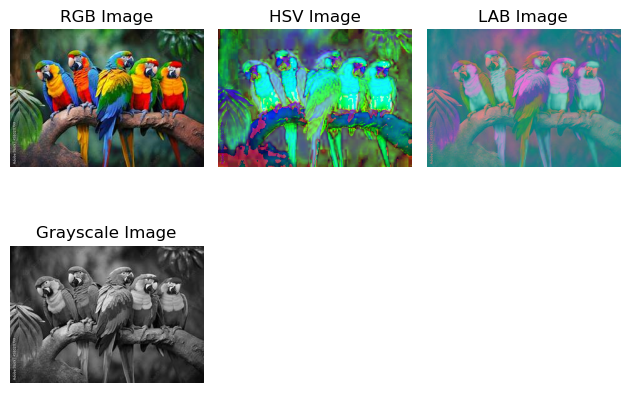

In [25]:
#Convert BGR to RGB
rgb_img= cv.cvtColor(img, cv.COLOR_BGR2RGB)

#Convert BGR to HSV
hsv_img= cv.cvtColor(img, cv.COLOR_BGR2HSV)

#Convert BGR to LAB
lab_img= cv.cvtColor(img, cv.COLOR_BGR2LAB)

#Convert BGR to Grayscale
gray_img= cv.cvtColor(img, cv.COLOR_BGR2GRAY)



plt.subplot(2, 3, 1)
plt.imshow(rgb_img)
plt.title("RGB Image")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(hsv_img)
plt.title("HSV Image")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(lab_img)
plt.title("LAB Image")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(gray_img, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")

#Adjust spacing between images
plt.tight_layout()
plt.show()

### Task 10: Image Sharpening
Apply cv2.blur() with a 5x5 kernel, then use cv2.filter2D() with sharpening kernels of varying strengths (e.g., [[0, -1, 0], [-1, 5, -1], [0, -1, 0]] and [[0, -2, 0], [-2, 9, -2], [0, -2, 0]]).
Compare between original and sharpened image after blurring.

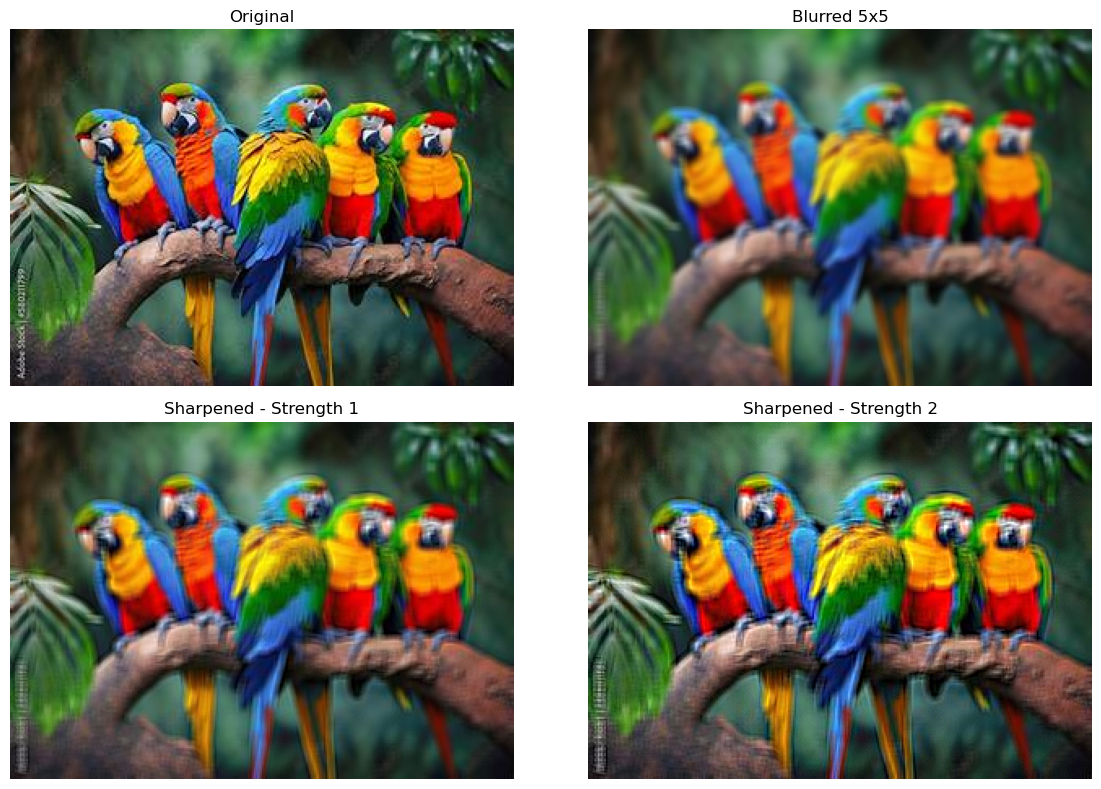

In [26]:
#Task 10
blurred = cv.blur(rgb_img, (5, 5))

#normal sharpening
kernel1= np.array([ [0, -1, 0],[-1, 5, -1],[0, -1, 0]])

#stronger sharpening
kernel2= np.array([[0, -2, 0],[-2, 9, -2],[0, -2, 0]])

#apply sharpening to BLURRED images

sharpened1= cv.filter2D(blurred, -1, kernel1)
sharpened2= cv.filter2D(blurred, -1, kernel2)

plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.imshow(rgb_img)
plt.title("Original")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(blurred)
plt.title("Blurred 5x5")
plt.axis("off")

#Normal sharpening
plt.subplot(2, 2, 3)
plt.imshow(sharpened1)
plt.title("Sharpened - Strength 1")
plt.axis("off")

#Stronger sharpening
plt.subplot(2, 2, 4)
plt.imshow(sharpened2)
plt.title("Sharpened - Strength 2")
plt.axis("off")

plt.tight_layout()
plt.show()

#The 5×5 blur makes the image smoother and less detailed. 
#Sharpening restores the edges, while stronger sharpening makes them more noticeable.

### Task 11: Add Salt and Pepper Noise to Image
Implement a function to add salt and pepper noise to an image. Control noise density (e.g., 0.05).

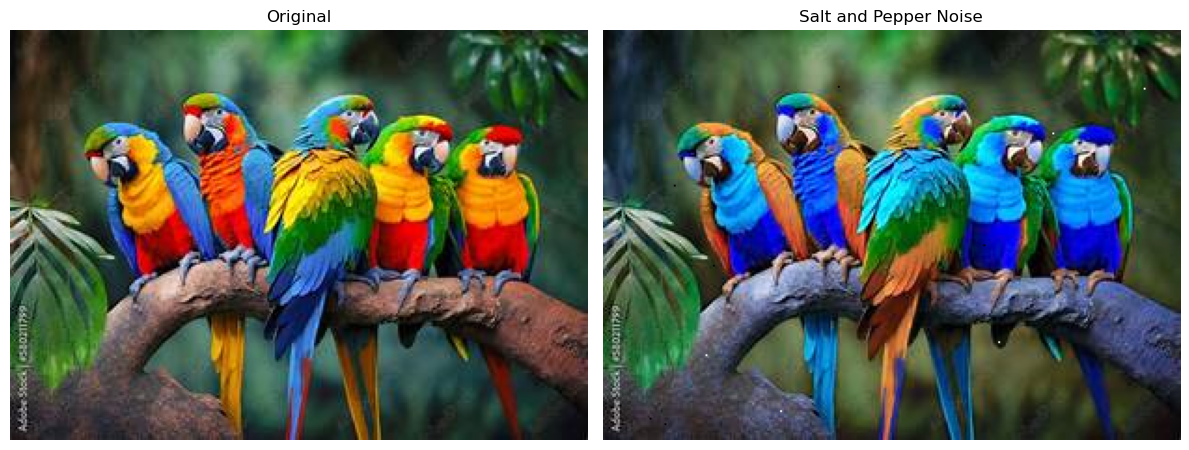

In [27]:
def add_salt_pepper_noise(image, density=0.05): #density controls how much noise i add, 0.05 means that 5% of pixals will become noise
    noisy = image.copy() #to modify the copy and dont change the original image

    total_pixels = image.shape[0] #height * image.shape[1] #width

    num_noise = int(total_pixels * density)

    rows = np.random.randint(0, image.shape[0], num_noise) 
    cols = np.random.randint(0, image.shape[1], num_noise)
    #these random rows and columns are going to get modified 

    half = num_noise // 2
    #half->salt, and other half->black

    noisy[rows[:half], cols[:half]] = 255 #add salt (changed pixels to white)
    noisy[rows[half:], cols[half:]] = 0 #add pepper (changed pixels to black)

    return noisy

noisy_img = add_salt_pepper_noise(img, 0.05)

plt.figure(figsize=(12, 5))

# Original image
plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title("Original")
plt.axis("off")

# Salt and pepper noise
plt.subplot(1, 2, 2)
plt.imshow(noisy_img)
plt.title("Salt and Pepper Noise")
plt.axis("off")

# Show the images
plt.tight_layout()
plt.show()

### Task 12: Remove Salt and Pepper Noise Using Median Filter
Apply cv.medianBlur() to a noisy image. Experiment with kernel sizes (3,5,7) and compare results.

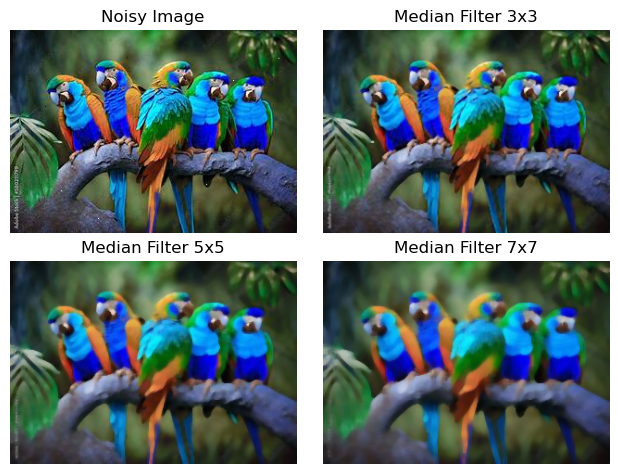

In [28]:
#Task 12
median3= cv.medianBlur(noisy_img, 3)
median5= cv.medianBlur(noisy_img, 5)
median7= cv.medianBlur(noisy_img, 7)

plt.subplot(2, 2, 1)
plt.imshow(noisy_img)
plt.title("Noisy Image")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(median3)
plt.title("Median Filter 3x3") #removes some noises and preserve details of the image
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(median5)
plt.title("Median Filter 5x5") #removes more noise but causes more smoothing
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(median7)
plt.title("Median Filter 7x7") #remove image details and causes very strong and noticable smoothing
plt.axis("off")

plt.tight_layout()
plt.show()

### Task 13: Implement Adaptive Median Filter
Write a custom function for adaptive median filtering. It should dynamically increase window size until noise is removed or max size is reached. Apply to a noisy image and compare with standard median.

In [ ]:
# Your code here
def adaptive_median_filter(image, max_size=7):
    # Implement logic: for each pixel, start with small window, increase if needed
    pass

# Test on noisy image

### Task 14: Implement Bilateral Filter Function
Write a Python function to perform bilateral filtering on an image. Use Gaussian weights for both spatial and intensity. Parameters: diameter, sigma_color, sigma_space. Compare with cv.bilateralFilter().

In [ ]:
# Your code here
def custom_bilateral_filter(image, diameter, sigma_color, sigma_space):
    # Implement using nested loops or vectorized (efficiently)
    # For each pixel, compute weighted sum based on distance and intensity diff
    pass

# Apply to image, display, and compare with OpenCV's version

### [BONUS] Task 15: Comprehensive Camera Task 
Combine: Live camera feed -> grayscale -> add noise -> remove with median -> sharpen. Display all stages in separate windows.

In [ ]:
# To read video from camera example:

camera_id = 0
delay = 400
window_name = 'frame'

cap = cv.VideoCapture(camera_id)

if not cap.isOpened():
    sys.exit()

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    cv.imshow(window_name, frame)
    if cv.waitKey(delay) & 0xFF == ord('q'):
        break

cap.release()
cv.destroyWindow(window_name)


# Your code here

### [BONUS]Task 16: Comprehensive Video Task
Similar to Task 18 but for a video file. Save the final processed video.

In [ ]:
# Your code here

### Task 17: Performance Comparison
Time the execution of standard median vs adaptive median on a large noisy image. Discuss when adaptive median filter is better.

In [ ]:
import time
# Your code here
# Use time.time() to measure